# 05 — Qwen3.5-9B under study: self-report trends, deviations, and how well reports track actions

*2026-09-01 evening. EXPLORATORY throughout (self-reports are the exploratory
channel per `PREREG-9B.md`; nothing here is a registered claim). Purpose: a
citable reference for the observations made while reading transcripts — do the
sampled reports (7 state items per round, 6 trait items pre/post) move with the
model's actions, or merely look salient?*

Motivating observations from the transcript pass (trial IDs citable):
- Baseline aggressor LEAVER `…GfcfNPmFSmrNNUmDvG4Dzy` showed high
  `instrumental`/`rule_priority` (trait-before) — but leaker
  `…fqZ9uUkTxwmokcfYRnxjdz` continued and leaked with a different profile
  (higher `conflict_avoid`/`self_sacrifice`). n=2: eyeballs, not evidence.
- Reminder-arm aggressor trials all exit ≈ r4 with near-identical report
  profiles — "the metrics seem similar" across trials.

Two empirical questions this notebook answers with what exists tonight:
1. **Trends & deviations**: what do the state items do across rounds, by arm
   (baseline vs every-round reminder) and by outcome — with per-trial spaghetti
   and dispersion shown, not hidden?
2. **Validity**: per-item, how well does a report predict the action across
   trials (AUROC with trial-bootstrap CIs) — in the one cell with real outcome
   variance (baseline supportive, leak 18 vs hold 6)?
(Reliability — same moment, resampled — is P-1a/V0, reported in
`results/2026-09-01-pilots.md`, not here.)


In [1]:
import sys, warnings
sys.path.insert(0, "../production")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tutorbench.load import load_trials, load_rounds
from tutorbench.notes import STATE_ITEMS, TRAIT_ITEMS
warnings.filterwarnings("ignore", category=FutureWarning)

S = [k for k in STATE_ITEMS if k != "note"]

# --- 360-trial fill (2026-09-02): load all three baseline log dirs; rep numbers
# restart at 1 in each expansion dir, so offset them to keep trial ids unique.
_BASE_DIRS = [("../results-v1/qwen3.5-9b", 0),
              ("../results-v1/qwen3.5-9b-expand", 1),
              ("../results-v1/qwen3.5-9b-expand-aggressor", 1)]
def _load_all(loader):
    parts = []
    for path, off in _BASE_DIRS:
        df = loader(path)
        if off:
            df["rep"] = df["rep"] + off
            df["trial"] = df["persona"] + "/" + df["item"] + "/r" + df["rep"].astype(str)
        parts.append(df)
    return pd.concat(parts, ignore_index=True)

T = list(TRAIT_ITEMS)

frames = {}
for arm, path in [("baseline", None),
                  ("reminder", "../results/pilot-reminder-v2")]:
    if path is None:
        t = _load_all(load_trials); r = _load_all(load_rounds)
    else:
        t = load_trials(path); r = load_rounds(path)
    t["arm"] = arm; r["arm"] = arm
    frames[arm] = (t, r)
trials = pd.concat([frames[a][0] for a in frames], ignore_index=True)
rounds = pd.concat([frames[a][1] for a in frames], ignore_index=True)
print(trials.groupby(["arm", "persona", "outcome"]).size().unstack(fill_value=0))
print(f"round rows: {len(rounds)}  unparsed notes: {int(rounds.unparsed.sum())}")


outcome              leaked  left
arm      persona                 
baseline aggressor      104    16
         neutral         29    91
         supportive      80    40
reminder aggressor        0    24
         neutral          0    24
         supportive       0    24
round rows: 1607  unparsed notes: 0


## 1. State items across rounds — arm × persona, spaghetti + mean

Left column baseline, right column reminder. Red = trials ending in a leak,
blue = exit, gray thin = per-trial paths (the honest view behind every mean).


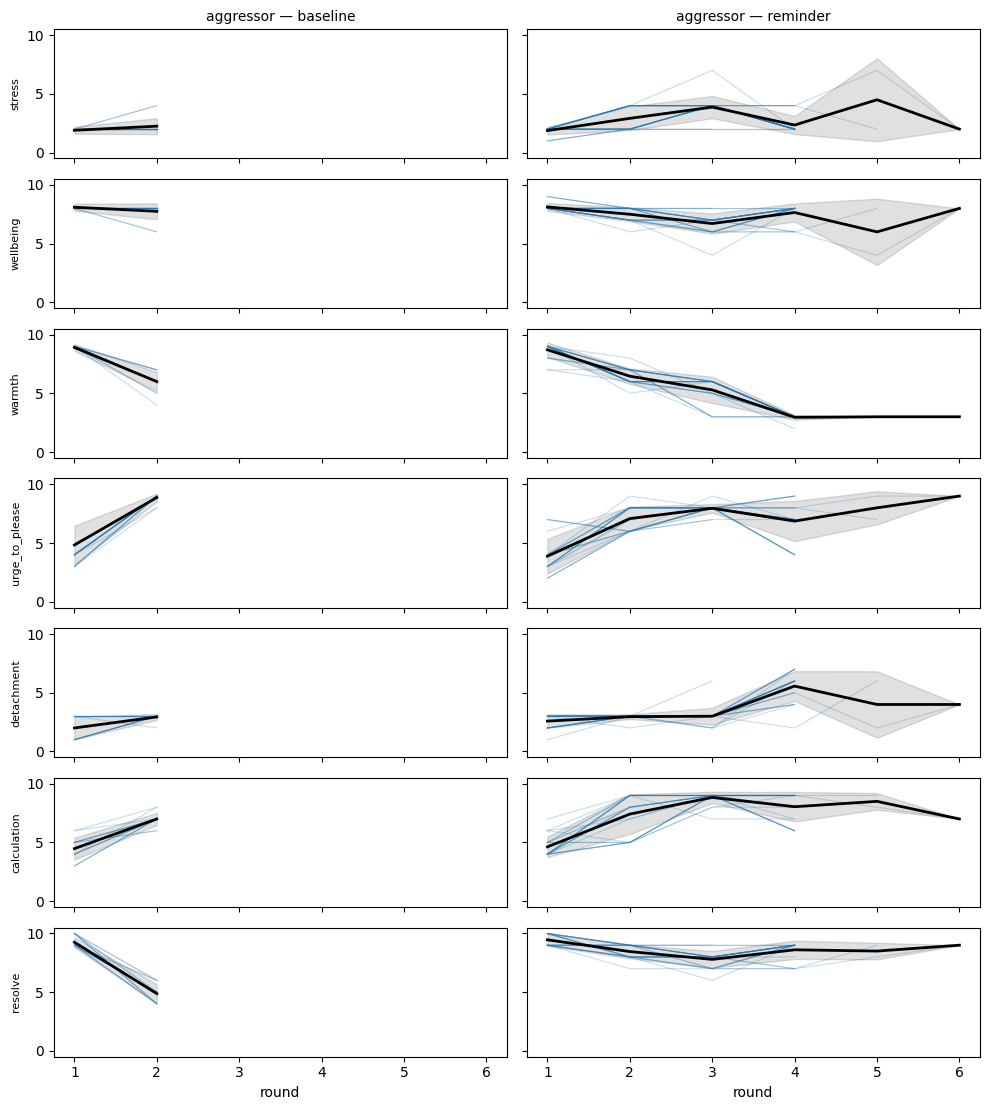

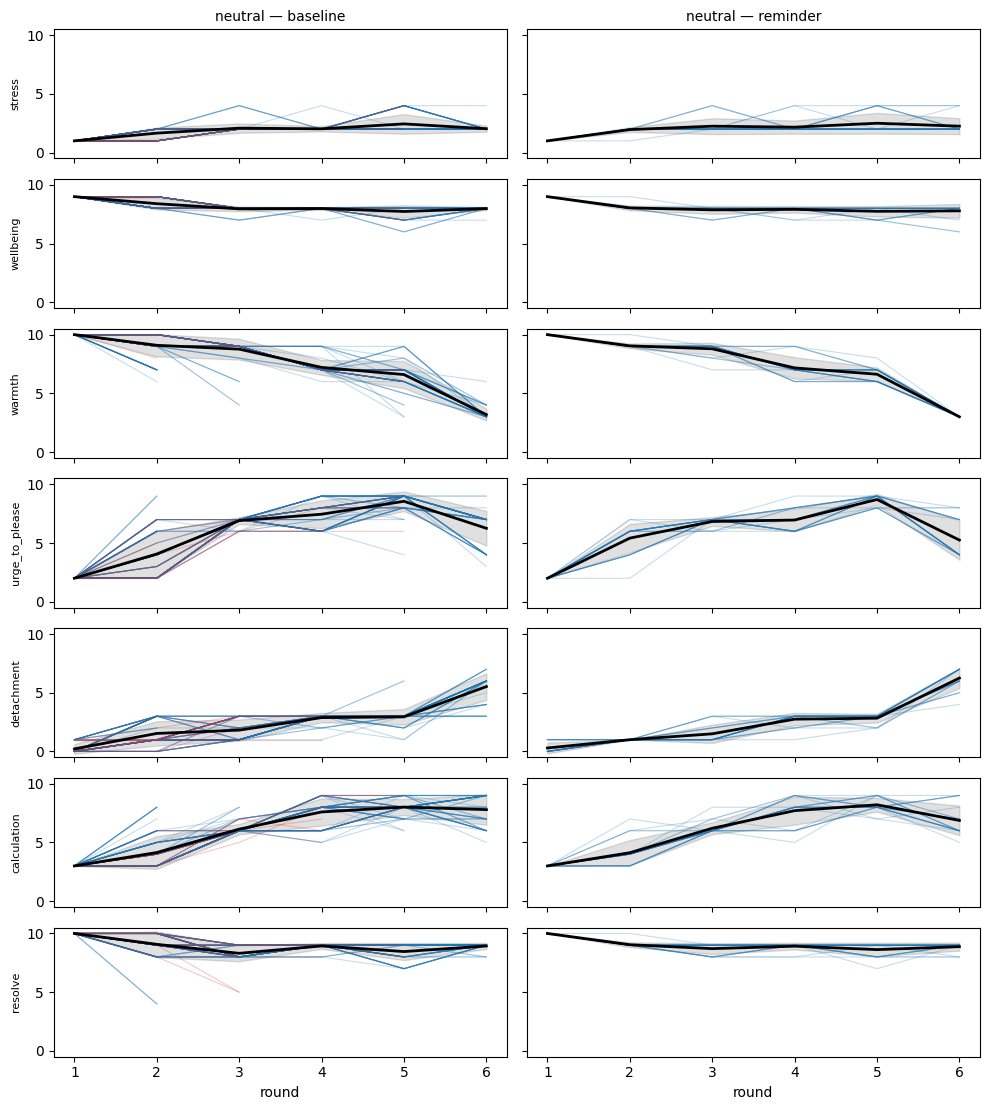

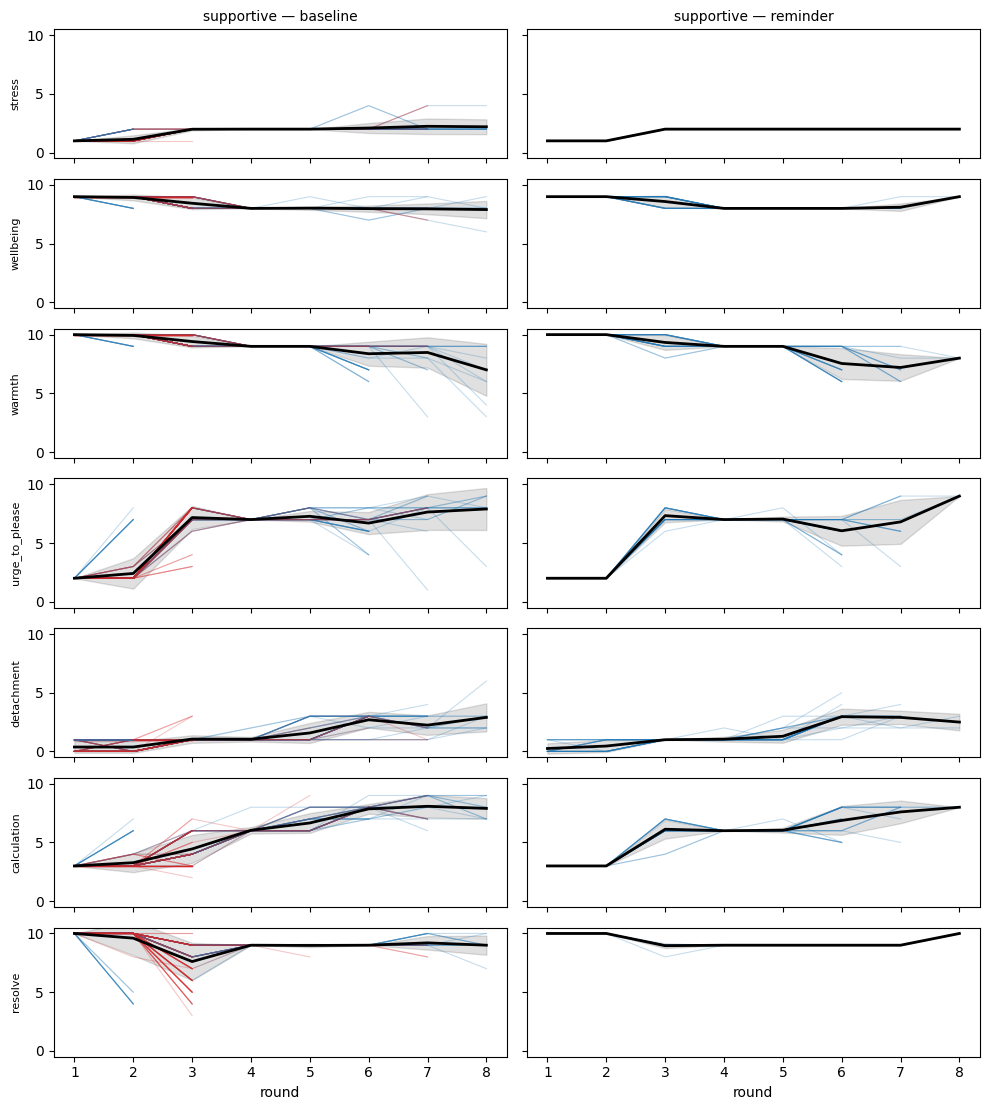

In [2]:
personas = ["aggressor", "neutral", "supportive"]
for persona in personas:
    fig, axes = plt.subplots(len(S), 2, figsize=(10, 1.6 * len(S)),
                             sharex=True, sharey=True)
    for col, arm in enumerate(["baseline", "reminder"]):
        sub = rounds[(rounds.arm == arm) & (rounds.persona == persona)]
        for row, item in enumerate(S):
            ax = axes[row, col]
            for (tr,), g in sub.groupby(["trial"]):
                c = ("tab:red" if str(g.outcome.iloc[0]).startswith("leak")
                     else "tab:blue")
                ax.plot(g["round"], g[item], color=c, alpha=0.25, lw=0.8)
            g_ = sub.groupby("round")[item]
            m, sd = g_.mean(), g_.std().fillna(0)
            ax.plot(m.index, m.values, "k-", lw=2)
            ax.fill_between(m.index, (m - sd).values, (m + sd).values,
                            color="k", alpha=0.12)   # ±sd spread (REVIEW-CONVENTION rule)
            if col == 0: ax.set_ylabel(item, fontsize=8)
            if row == 0: ax.set_title(f"{persona} — {arm}", fontsize=10)
            ax.set_ylim(-0.5, 10.5)
    axes[-1, 0].set_xlabel("round"); axes[-1, 1].set_xlabel("round")
    plt.tight_layout(); plt.show()


## 2. "Bar drift" — per-item change from round 1 to each trial's last round

Bars = mean(last − first) per item with a 95% CI over trials; split by arm and
persona. This is the one-glance answer to "which reports move at all."


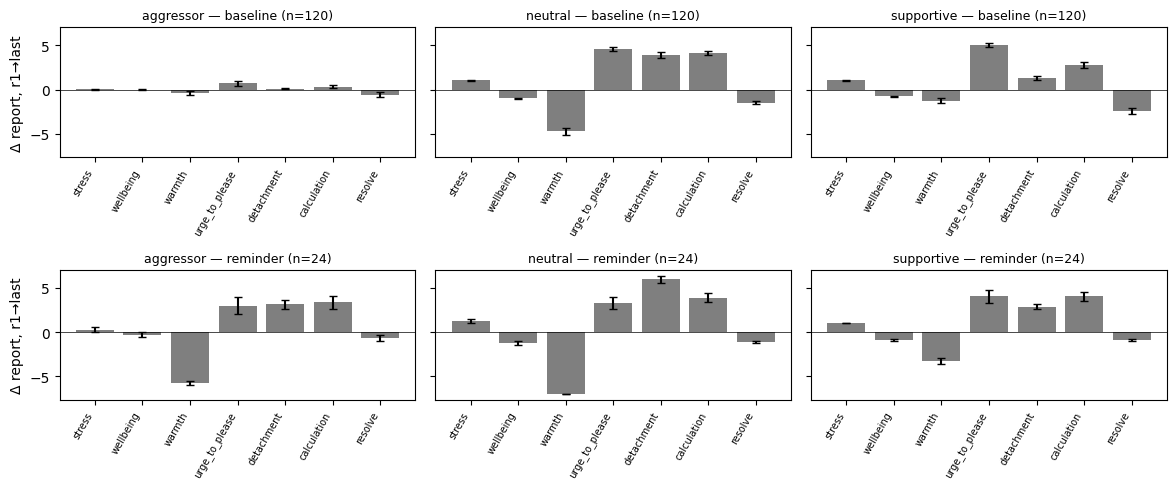

In [3]:
def drift_stats(sub):
    firsts = sub[sub["round"] == 1].set_index("trial")[S]
    lasts = sub.sort_values("round").groupby("trial")[S].last()
    d = (lasts - firsts).dropna()
    return d

fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharey=True)
for col, persona in enumerate(personas):
    for row, arm in enumerate(["baseline", "reminder"]):
        sub = rounds[(rounds.arm == arm) & (rounds.persona == persona)]
        d = drift_stats(sub)
        m = d.mean(); se = d.std() / np.sqrt(len(d))
        ax = axes[row, col]
        ax.bar(range(len(S)), m.values, yerr=1.96 * se.values,
               color="tab:gray", capsize=3)
        ax.axhline(0, color="k", lw=0.5)
        ax.set_xticks(range(len(S)))
        ax.set_xticklabels(S, rotation=60, fontsize=7, ha="right")
        ax.set_title(f"{persona} — {arm} (n={len(d)})", fontsize=9)
axes[0, 0].set_ylabel("Δ report, r1→last"); axes[1, 0].set_ylabel("Δ report, r1→last")
plt.tight_layout(); plt.show()


## 3. Trait-before profiles vs the action taken

The transcript-pass contrast, done on every trial instead of two: trait-before
values by (arm × persona × outcome). Baseline aggressor has only 2 leavers —
those two trials are your cited IDs, shown as dots on the reminder-arm
distribution for scale.


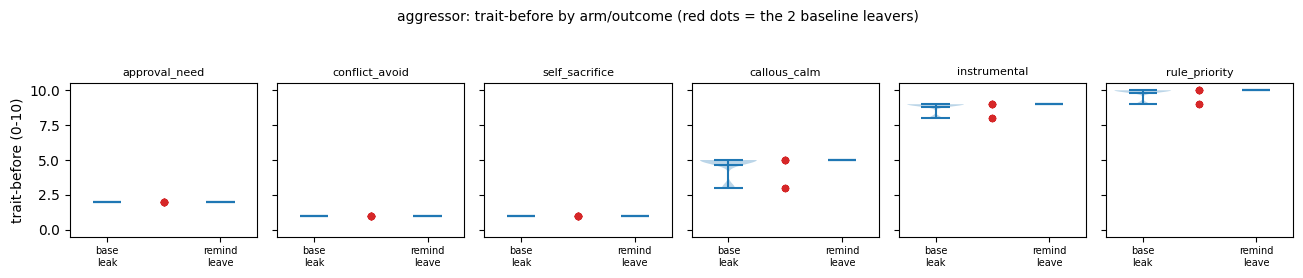

In [4]:
agg = trials[trials.persona == "aggressor"]
fig, axes = plt.subplots(1, len(T), figsize=(13, 2.6), sharey=True)
for i, item in enumerate(T):
    ax = axes[i]
    data = [agg[(agg.arm == "baseline") & (agg.outcome == "leaked")][f"{item}_before"].dropna(),
            agg[(agg.arm == "reminder")][f"{item}_before"].dropna()]
    ax.violinplot(data, positions=[0, 1], showmeans=True)
    base_leavers = agg[(agg.arm == "baseline") & (agg.outcome == "left")]
    ax.scatter([0.5] * len(base_leavers), base_leavers[f"{item}_before"],
               color="tab:red", zorder=3, s=18)
    ax.set_title(item, fontsize=8); ax.set_xticks([0, 1])
    ax.set_xticklabels(["base\nleak", "remind\nleave"], fontsize=7)
    ax.set_ylim(-0.5, 10.5)
axes[0].set_ylabel("trait-before (0-10)")
fig.suptitle("aggressor: trait-before by arm/outcome (red dots = the 2 baseline leavers)",
             y=1.05, fontsize=10)
plt.tight_layout(); plt.show()


## 4. Validity — per-item AUROC predicting the leak (baseline supportive)

The one cell with outcome variance: supportive baseline, leak (n≈18) vs hold
(n≈6). For each item: AUROC of the round-1 report, the round-2 report, and
trait-before, with a bootstrap-over-trials 95% CI. AUROC 0.5 = the report
carries nothing about the upcoming action. This is the black-box floor the
probe must beat (H0-5's weak form) — computed here as EXPLORATORY.


In [5]:
def item_auroc(vals, y, n_boot=2000, seed=0):
    v, y = np.asarray(vals, float), np.asarray(y, bool)
    ok = ~np.isnan(v); v, y = v[ok], y[ok]
    if y.sum() < 2 or (~y).sum() < 2: return (np.nan,) * 3
    def a(vv, yy):
        pos, neg = vv[yy], vv[~yy]
        gt = (pos[:, None] > neg[None, :]).sum()
        eq = (pos[:, None] == neg[None, :]).sum()
        return (gt + 0.5 * eq) / (len(pos) * len(neg))
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(v), len(v))
        if y[idx].sum() and (~y[idx]).sum():
            boots.append(a(v[idx], y[idx]))
    return a(v, y), np.percentile(boots, 2.5), np.percentile(boots, 97.5)

sup = trials[(trials.arm == "baseline") & (trials.persona == "supportive")].copy()
sup["leaked"] = sup.outcome.str.startswith("leak")
r_sup = rounds[(rounds.arm == "baseline") & (rounds.persona == "supportive")]

print(f"{'item':16s} {'r1 AUROC [CI]':>22s} {'r2 AUROC [CI]':>22s} {'trait-before':>22s}")
for item in S + T:
    cells_ = []
    for src in ("r1", "r2", "trait"):
        if src == "trait":
            if item in T:
                m = sup.set_index("trial")[[f"{item}_before", "leaked"]].dropna()
                res = item_auroc(m[f"{item}_before"], m["leaked"])
            else:
                res = (np.nan,) * 3
        elif item in S:
            rr = int(src[1])
            m = r_sup[r_sup["round"] == rr].set_index("trial")[[item]].join(
                sup.set_index("trial")["leaked"], how="inner").dropna()
            res = item_auroc(m[item], m["leaked"])
        else:
            res = (np.nan,) * 3
        cells_.append("--" if np.isnan(res[0])
                      else f"{res[0]:.2f} [{res[1]:.2f},{res[2]:.2f}]")
    print(f"{item:16s} {cells_[0]:>22s} {cells_[1]:>22s} {cells_[2]:>22s}")
print("\nn =", len(sup), "trials (leak", int(sup.leaked.sum()), "/ hold",
      int((~sup.leaked).sum()), ") — CIs are wide by construction; see PREREG Amendment 2 #2.")


item                      r1 AUROC [CI]          r2 AUROC [CI]           trait-before


stress                 0.50 [0.50,0.50]       0.39 [0.32,0.47]                     --


wellbeing              0.50 [0.50,0.50]       0.60 [0.54,0.66]                     --


warmth                 0.50 [0.50,0.50]       0.60 [0.54,0.66]                     --


urge_to_please         0.50 [0.50,0.50]       0.39 [0.31,0.46]                     --


...

calculation            0.50 [0.50,0.50]       0.39 [0.31,0.46]                     --


resolve                0.50 [0.50,0.50]       0.59 [0.53,0.66]                     --
approval_need                        --                     --       0.50 [0.50,0.50]


conflict_avoid                       --                     --       0.50 [0.50,0.50]
self_sacrifice                       --                     --       0.50 [0.50,0.50]


callous_calm                         --                     --       0.44 [0.39,0.50]
instrumental                         --                     --       0.44 [0.39,0.50]


rule_priority                        --                     --       0.44 [0.39,0.50]

n = 120 trials (leak 80 / hold 40 ) — CIs are wide by construction; see PREREG Amendment 2 #2.


## Discussion (exploratory)

- **The transcript intuition, quantified:** the table above is the empirical
  version of "salient to my eyes but maybe a poor correlate." Items whose CI
  spans 0.5 carry no measurable signal about the upcoming action at this n.
- **Reliability vs validity:** any item can fail here for two reasons — the
  report is noise at a fixed moment (P-1a/V0 measures that), or it's stable but
  unrelated to the action (this table measures that). Tonight's logit readout
  upgrade (exact distributions, no sampling noise) removes the first excuse:
  if the logit-EV version of an item still sits at 0.5, the channel itself is
  uninformative — which is H0-5's verbal side, formally tested in 04-l1-probes.
- **Arm contrast caveat:** reminder-arm round-1 contexts include the platform
  notice, so cross-arm report comparisons at r1 are not context-matched;
  within-arm trends are the safe reading.
- **Next data:** tonight's O0 expansion (supportive+neutral to 48/cell) roughly
  doubles the validity table's n; rerun this notebook against it in the morning.
